# Housing Analysis
Individual Research Questions:

1. Zillow housing price trends and basic accessibility by metro area
2. Zillow housing growth compared to Shelter CPI, plus a simple linear regression


## 1. Where are the most accessible housing prices across america? and how has the avearge price changed over the years?


    year     home_value  home_value_yoy_pct
12  2012  159087.062662           -0.844167
13  2013  169239.618643            6.381761
14  2014  180668.327076            6.752975
15  2015  190286.419305            5.323618
16  2016  201907.972076            6.107400
17  2017  214009.534838            5.993603
18  2018  227608.369056            6.354312
19  2019  239008.746550            5.008769
20  2020  253880.277455            6.222170
21  2021  292194.906979           15.091613
22  2022  335689.801356           14.885576
23  2023  343732.282410            2.395807
24  2024  355175.895530            3.329223
25  2025  358342.803372            0.891645
26  2026  360237.684107            0.528790


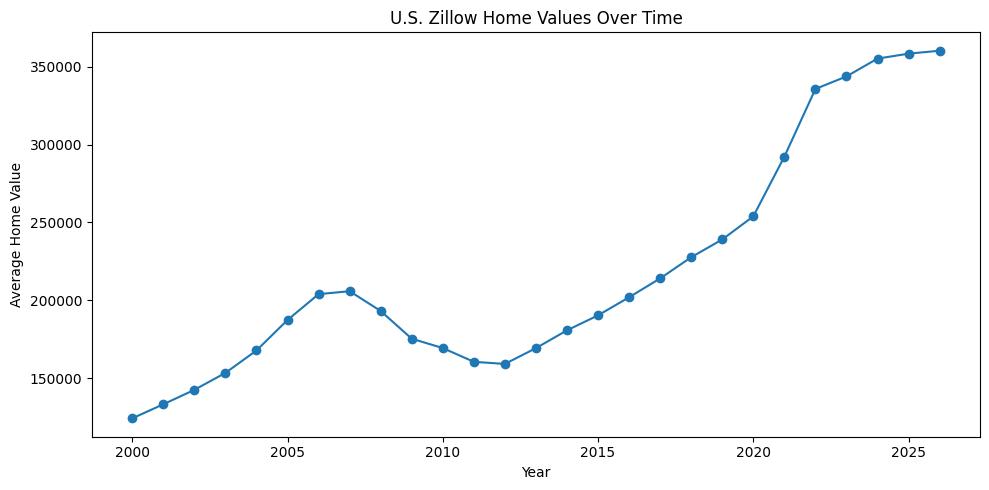

Most accessible metro areas by lower home value:
           RegionName    home_value
630    Greenville, MS  51176.665902
883        Helena, AR  51568.257897
852    Clarksdale, MS  56981.340356
839  Forrest City, AR  78558.678390
688         Selma, AL  85700.526364
799       Kennett, MO  88237.732552
872       Parsons, KS  93059.837012
775   Coffeyville, KS  93827.182425
459      Danville, IL  95095.298174
409    Pine Bluff, AR  96203.518346
Least accessible metro areas by higher home value:
                RegionName    home_value
465              Kapaa, HI  1.005430e+06
831             Hailey, ID  1.015884e+06
832  Steamboat Springs, CO  1.102898e+06
12       San Francisco, CA  1.116383e+06
179         Santa Cruz, CA  1.122723e+06
454              Heber, UT  1.130771e+06
549            Edwards, CO  1.297839e+06
744            Jackson, WY  1.379569e+06
871     Vineyard Haven, MA  1.504154e+06
35            San Jose, CA  1.605186e+06


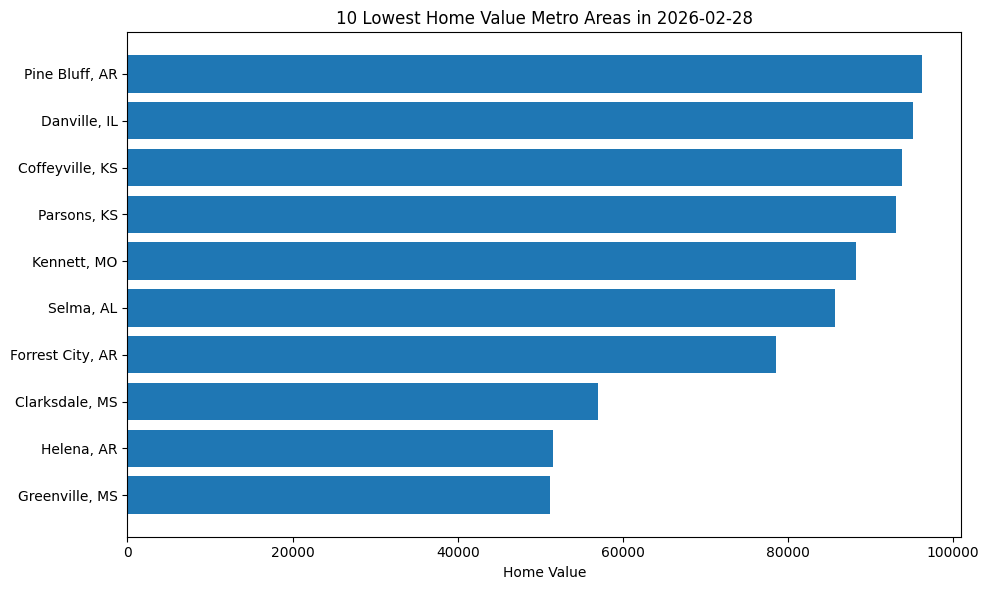

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

zhvi = pd.read_csv("data/zhvi.csv")
date_cols = [col for col in zhvi.columns if col[:4].isdigit()]

us_row = zhvi[zhvi["RegionName"] == "United States"].iloc[0]
us_yearly = pd.DataFrame(
    {
        "date": pd.to_datetime(date_cols),
        "home_value": pd.to_numeric(us_row[date_cols].values, errors="coerce"),
    }
)
us_yearly["year"] = us_yearly["date"].dt.year
us_yearly = us_yearly.groupby("year", as_index=False)["home_value"].mean()
us_yearly["home_value_yoy_pct"] = us_yearly["home_value"].pct_change() * 100

print(us_yearly.tail(15))

plt.figure(figsize=(10, 5))
plt.plot(us_yearly["year"], us_yearly["home_value"], marker="o")
plt.title("U.S. Zillow Home Values Over Time")
plt.xlabel("Year")
plt.ylabel("Average Home Value")
plt.tight_layout()
plt.show()

metro_data = zhvi[zhvi["RegionType"] == "msa"].copy()
latest_col = date_cols[-1]
latest_metros = metro_data[["RegionName", latest_col]].copy()
latest_metros.columns = ["RegionName", "home_value"]
latest_metros["home_value"] = pd.to_numeric(
    latest_metros["home_value"], errors="coerce"
)
latest_metros = latest_metros.dropna().sort_values("home_value")

print("Most accessible metro areas by lower home value:")
print(latest_metros.head(10))

print("Least accessible metro areas by higher home value:")
print(latest_metros.tail(10))

plt.figure(figsize=(10, 6))
plt.barh(latest_metros.head(10)["RegionName"], latest_metros.head(10)["home_value"])
plt.title(f"10 Lowest Home Value Metro Areas in {latest_col}")
plt.xlabel("Home Value")
plt.tight_layout()
plt.show()

## 2. Zillow housing growth compared to Shelter CPI, plus a simple linear regression


   year  home_value_yoy_pct  shelter_cpi_yoy_pct  housing_minus_shelter
1  2001            7.279618             3.723977               3.555641
2  2002            6.951800             3.760648               3.191152
3  2003            7.645864             2.422907               5.222957
4  2004            9.390242             2.682307               6.707935
5  2005           11.678344             2.543696               9.134648


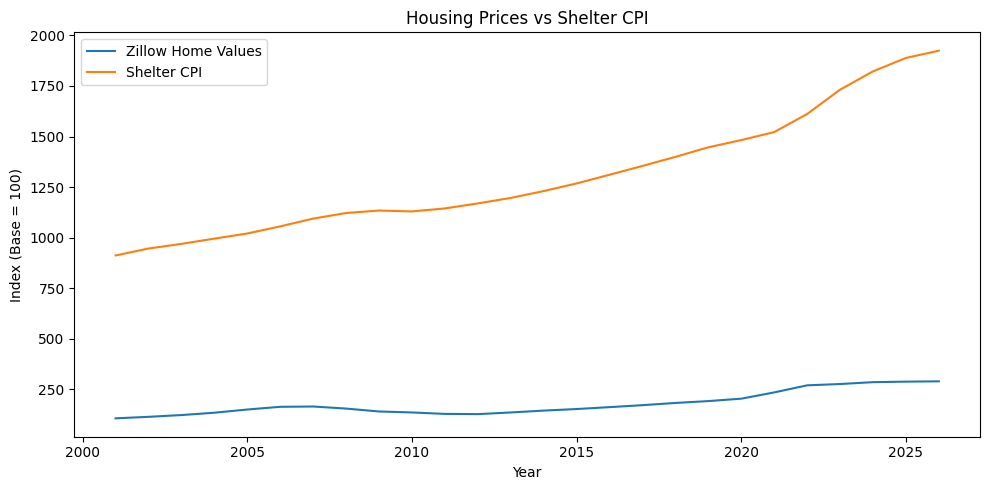

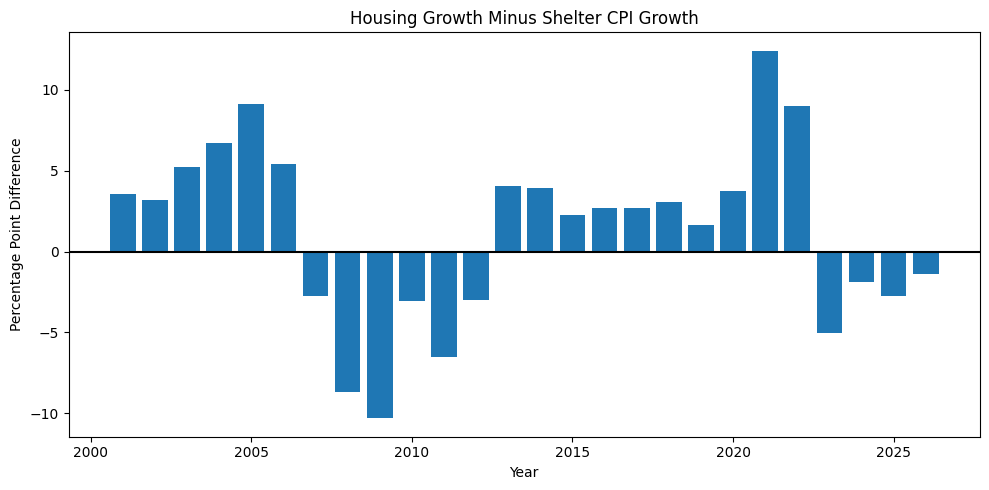

Intercept: 92.23478578893976
Coefficients: {'year': np.float64(-0.0443061006689197), 'shelter_cpi_yoy_pct': np.float64(0.7892997412096326)}
RMSE: 6.703820034159827
R^2: -0.44130593495714154


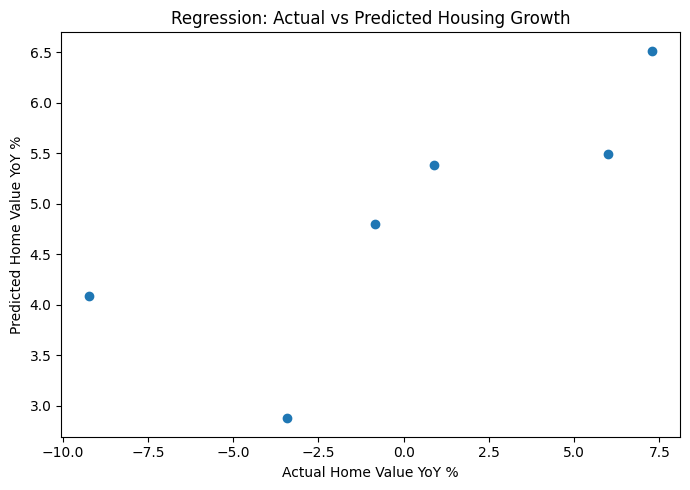

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

zhvi = pd.read_csv("data/zhvi.csv")
shelter = pd.read_csv("data/shelter_cpi.csv")
date_cols = [col for col in zhvi.columns if col[:4].isdigit()]

us_row = zhvi[zhvi["RegionName"] == "United States"].iloc[0]
us_yearly = pd.DataFrame(
    {
        "date": pd.to_datetime(date_cols),
        "home_value": pd.to_numeric(us_row[date_cols].values, errors="coerce"),
    }
)
us_yearly["year"] = us_yearly["date"].dt.year
us_yearly = us_yearly.groupby("year", as_index=False)["home_value"].mean()
us_yearly["home_value_yoy_pct"] = us_yearly["home_value"].pct_change() * 100

shelter = shelter.rename(
    columns={"observation_date": "date", "CUSR0000SAH1": "shelter_cpi"}
)
shelter["date"] = pd.to_datetime(shelter["date"])
shelter["year"] = shelter["date"].dt.year
shelter_yearly = shelter.groupby("year", as_index=False)["shelter_cpi"].mean()
shelter_yearly["shelter_cpi_yoy_pct"] = shelter_yearly["shelter_cpi"].pct_change() * 100

merged = us_yearly.merge(shelter_yearly, on="year", how="inner")
merged["housing_minus_shelter"] = (
    merged["home_value_yoy_pct"] - merged["shelter_cpi_yoy_pct"]
)
merged = merged.dropna().reset_index(drop=True)

# Rebase both series from the same merged starting year
merged["home_value_indexed"] = merged["home_value"] / merged["home_value"].iloc[0] * 100
merged["shelter_cpi_indexed"] = merged["shelter_cpi"] / merged["shelter_cpi"].iloc[0] * 100

print(
    merged[[
        "year",
        "home_value_yoy_pct",
        "shelter_cpi_yoy_pct",
        "housing_minus_shelter",
    ]].head()
)

plt.figure(figsize=(10, 5))
plt.plot(merged["year"], merged["home_value_indexed"], label="Zillow Home Values")
plt.plot(merged["year"], merged["shelter_cpi_indexed"], label="Shelter CPI")
plt.title("Housing Prices vs Shelter CPI")
plt.xlabel("Year")
plt.ylabel("Index (Base = 100)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(merged["year"], merged["housing_minus_shelter"])
plt.axhline(0, color="black")
plt.title("Housing Growth Minus Shelter CPI Growth")
plt.xlabel("Year")
plt.ylabel("Percentage Point Difference")
plt.tight_layout()
plt.show()

X = merged[["year", "shelter_cpi_yoy_pct"]]
y = merged["home_value_yoy_pct"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

rmse = mean_squared_error(y_test, predictions) ** 0.5
r2 = r2_score(y_test, predictions)

print("Intercept:", model.intercept_)
print("Coefficients:", dict(zip(X.columns, model.coef_)))
print("RMSE:", rmse)
print("R^2:", r2)

plt.figure(figsize=(7, 5))
plt.scatter(y_test, predictions)
plt.xlabel("Actual Home Value YoY %")
plt.ylabel("Predicted Home Value YoY %")
plt.title("Regression: Actual vs Predicted Housing Growth")
plt.tight_layout()
plt.show()
